In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [13]:
import os
os.makedirs('data', exist_ok=True)

In [14]:
#load and split the data

from sklearn.model_selection import train_test_split

X = pd.read_csv('data/features.csv')
y = pd.read_csv('data/target.csv').squeeze()

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Label mapping: {'Adult': np.int64(0), 'Kids': np.int64(1), 'Teen': np.int64(2)}
Training samples: 7035
Test samples: 1759


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=3000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.68      0.69      0.69       818
           1       0.82      0.79      0.81       238
           2       0.60      0.60      0.60       703

    accuracy                           0.67      1759
   macro avg       0.70      0.69      0.70      1759
weighted avg       0.67      0.67      0.67      1759


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.67      0.70      0.69       818
           1       0.81      0.77      0.79       238
           2       0.60      0.57      0.59       703

    accuracy                           0.66      1759
   macro avg       0.69      0.68      0.69      1759
weighted avg       0.66      0.66      0.66      1759



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:40:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
              precision    recall  f1-score   support

           0       0.69      0.76      0.72       818
           1       0.85      0.78      0.81       238
           2       0.64      0.58      0.61       703

    accuracy                           0.69      1759
   macro avg       0.73      0.71      0.71      1759
weighted avg       0.69      0.69      0.69      1759



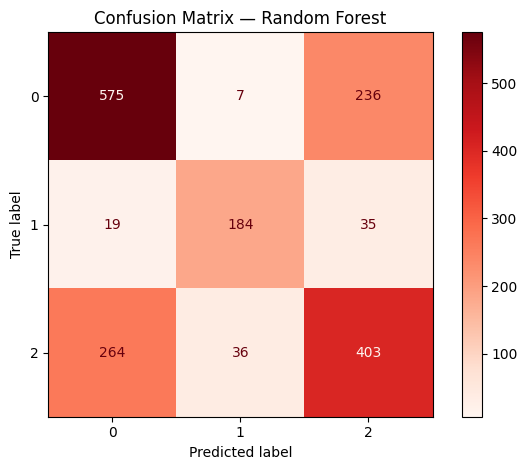

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = models['Random Forest']  # swap with whichever scored best
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Reds')
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

Visualization of the best model's confusion matrix

/tmp/ipykernel_4507/2543173632.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='Reds_r')


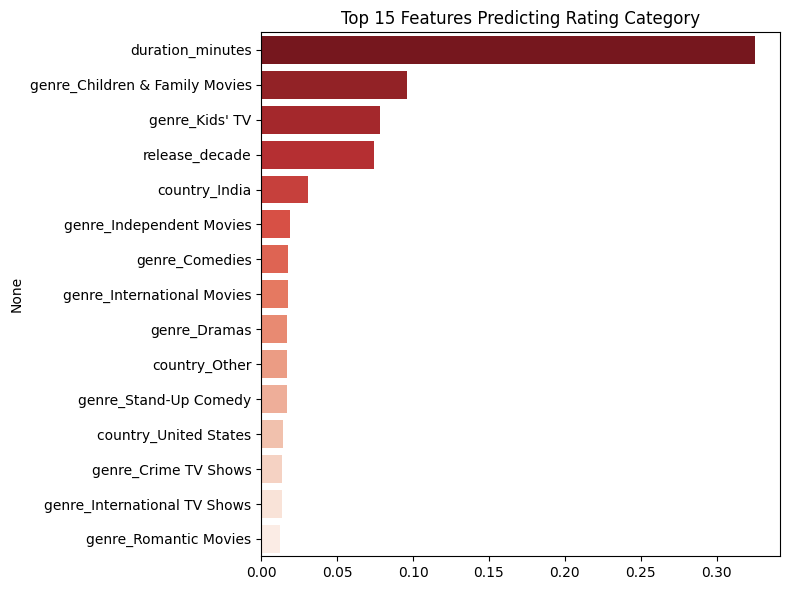

In [19]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index, palette='Reds_r')
plt.title('Top 15 Features Predicting Rating Category')
plt.tight_layout()
plt.show()


```

This answers: *"What content signals most strongly predict whether something is for kids, teens, or adults?"* — that's your headline ML insight.

---

## Phase 4 — Polish & Publish

**README.md** is the most important file. It's what a recruiter reads. Write it like this:
```
# Netflix Content Intelligence & Rating Predictor

## Problem
Can we predict the audience rating category of Netflix content
from metadata alone — genre, country, duration, and type?

## Dataset
Netflix Titles (Kaggle) — 8,807 titles, cleaned and engineered

## Key Insights
- 74% of Netflix content is rated for teens or adults
- International Dramas and Documentaries dominate the library
- Release decade and genre are the strongest rating predictors

## Models Trained
| Model | Accuracy |
|-------|----------|
| Logistic Regression | ~% |
| Random Forest | ~% |
| XGBoost | ~% |

## How to Run
pip install -r requirements.txt
jupyter notebook 01_EDA.ipynb